# Analyse Exploratoire des Données (EDA)
Exploration des cycles temporels, de l'impact météorologique et des effets calendaires.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

MOIS = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
JOURS_SEMAINE = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

In [41]:
df = pd.read_csv('../data/processed/dataset_final.csv')
df['timestamp_paris'] = pd.to_datetime(df['timestamp_paris'], utc=True).dt.tz_convert('Europe/Paris')
df.head()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,56569.0,Données définitives,1,4,1,1,2016,Hiver,...,7.161313,6.036176,92.699710,141.342131,1.398133,87.926456,0.000000,False,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,55506.5,Données définitives,2,4,1,1,2016,Hiver,...,6.617959,5.651121,93.667847,145.044523,1.230233,87.187606,0.000000,False,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,52404.0,Données définitives,3,4,1,1,2016,Hiver,...,6.074606,5.266066,94.635983,148.746916,1.062332,86.448757,0.000000,False,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,49776.0,Données définitives,4,4,1,1,2016,Hiver,...,5.531252,4.881011,95.604120,152.449308,0.894432,86.546508,0.000000,False,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,48761.0,Données définitives,5,4,1,1,2016,Hiver,...,5.303669,4.737056,96.119515,167.471301,1.000966,82.983612,0.003004,False,True,3


In [42]:
df.tail()

,timestamp_utc,timestamp_paris,consommation_mw,source_donnee,heure,jour_semaine,jour_annee,mois,annee,saison,...,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,weekend,ferie,vacances
94219,2026-09-30 19:00:00+00:00,2026-09-30 21:00:00+02:00,44329.75,Données temps réel,21,2,273,9,2026,Automne,...,20.307814,16.505022,80.529951,186.856153,3.528280,97.594697,0.416259,False,False,0
94220,2026-09-30 20:00:00+00:00,2026-09-30 22:00:00+02:00,43508.75,Données temps réel,22,2,273,9,2026,Automne,...,19.692859,16.506133,83.211186,180.497148,3.361084,97.594697,0.494731,False,False,0
94221,2026-09-30 21:00:00+00:00,2026-09-30 23:00:00+02:00,42950.00,Données temps réel,23,2,273,9,2026,Automne,...,19.077903,16.507243,85.892421,174.138142,3.193888,98.059291,0.573203,False,False,0
94222,2026-09-30 22:00:00+00:00,2026-10-01 00:00:00+02:00,41006.75,Données temps réel,0,3,274,10,2026,Automne,...,18.788142,16.184159,85.651284,187.024246,3.223299,98.801464,0.522770,False,False,0
94223,2026-09-30 23:00:00+00:00,2026-10-01 01:00:00+02:00,38884.75,Données temps réel,1,3,274,10,2026,Automne,...,18.498380,15.861074,85.410147,199.910350,3.252710,99.046795,0.472337,False,False,0


## 0. Analyse Descriptive

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94224 entries, 0 to 94223
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype                       
---  ------                                 --------------  -----                       
 0   timestamp_utc                          94224 non-null  str                         
 1   timestamp_paris                        94224 non-null  datetime64[us, Europe/Paris]
 2   consommation_mw                        94224 non-null  float64                     
 3   source_donnee                          94224 non-null  str                         
 4   heure                                  94224 non-null  int64                       
 5   jour_semaine                           94224 non-null  int64                       
 6   jour_annee                             94224 non-null  int64                       
 7   mois                                   94224 non-null  int64                       
 8   annee  

In [44]:
df.describe()

,consommation_mw,heure,jour_semaine,jour_annee,mois,annee,confinement_numero,temperature_c,temperature_point_rosee_c,humidite_pct,...,nebulosite,precip_1h_mm,temperature_c_pondere_pop,temperature_point_rosee_c_pondere_pop,humidite_pct_pondere_pop,vent_direction_deg_pondere_pop,vent_vitesse_ms_pondere_pop,nebulosite_pondere_pop,precip_1h_mm_pondere_pop,vacances
count,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,94224.000000,3215.000000,94117.000000,94117.000000,94117.000000,...,93763.000000,94059.000000,94117.000000,94117.000000,94117.000000,94117.000000,94117.000000,93763.000000,94059.000000,94224.000000
mean,52158.201138,11.499989,2.999958,179.968766,6.418641,2020.882174,1.813686,13.734622,8.668403,74.614965,...,81.117666,0.072721,13.586453,8.361766,73.983477,194.135836,3.247108,76.891669,0.073664,1.034927
std,11400.166005,6.922239,2.000239,104.485856,3.417064,3.104189,0.783979,7.030407,4.996480,14.215062,...,22.062744,0.158232,7.189403,5.048673,14.961883,52.651983,1.412013,24.289444,0.175096,1.317078
min,29364.500000,0.000000,0.000000,1.000000,1.000000,2016.000000,1.000000,-5.876923,-12.630769,23.384615,...,0.000000,0.000000,-6.633710,-14.014853,19.972188,33.215159,0.235636,0.000000,0.000000,0.000000
25%,43609.375000,5.750000,1.000000,90.000000,3.000000,2018.000000,1.000000,8.428205,4.987179,65.384615,...,76.666667,0.000000,8.188325,4.677893,64.321210,154.990831,2.208435,68.238336,0.000000,0.000000
50%,50312.000000,11.500000,3.000000,179.000000,6.000000,2021.000000,2.000000,13.153846,8.838462,77.974359,...,89.166667,0.002564,13.030532,8.538233,77.499083,194.104523,3.049817,85.734649,0.000102,0.000000
75%,59694.125000,17.250000,5.000000,268.000000,9.000000,2024.000000,2.000000,18.789744,12.812821,85.923077,...,95.238095,0.074359,18.729686,12.528475,85.871129,233.059291,4.083639,94.435384,0.066779,3.000000
max,96129.500000,23.000000,6.000000,366.000000,12.000000,2026.000000,3.000000,37.684615,20.853846,98.461538,...,100.982456,4.730769,38.151345,20.666870,98.804401,340.849633,11.461247,100.982456,7.612317,3.000000


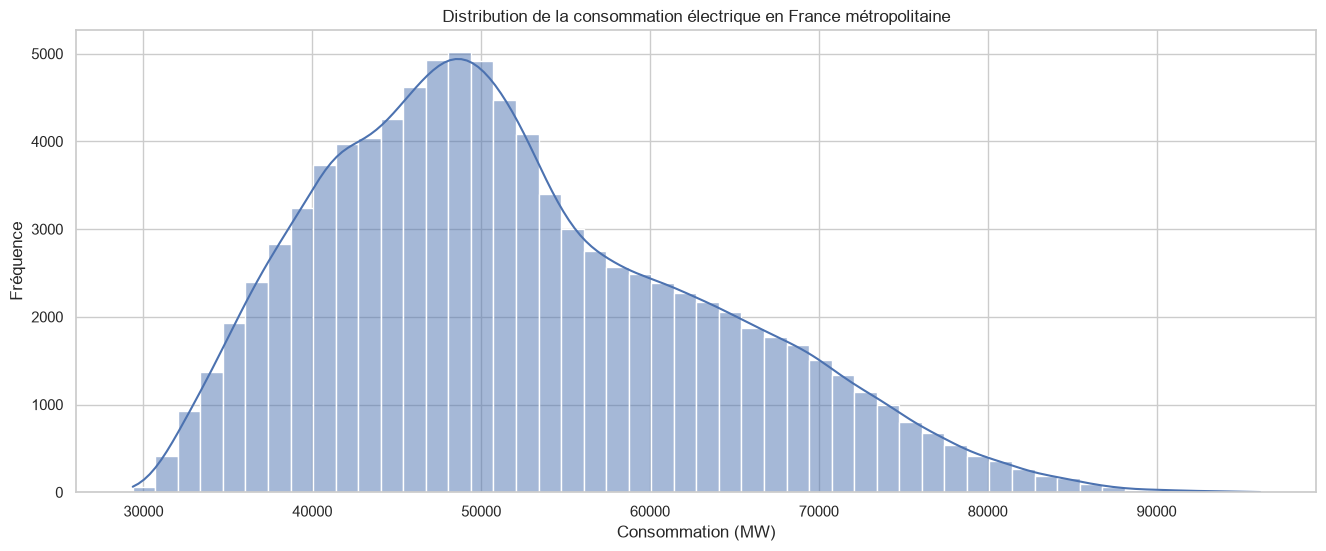

In [45]:
plt.figure(figsize=(16, 6))
sns.histplot(
    df["consommation_mw"],
    bins=50,
	kde=True,
)

plt.title("Distribution de la consommation électrique en France métropolitaine")
plt.xlabel("Consommation (MW)")
plt.ylabel("Fréquence")
plt.show()

In [46]:
valeurs_manquantes = df.isna().sum()
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes > 0]

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

nombre_doublons = df["timestamp_paris"].duplicated().sum()
print(f"\nNombre de timestamps en doublon : {nombre_doublons}")

ecart = df["timestamp_paris"].diff()
print("\nIntervalles :")
print(ecart.value_counts())

Nombre de valeurs manquantes par colonne :
confinement_numero                       91009
temperature_c                              107
temperature_point_rosee_c                  107
humidite_pct                               107
vent_direction_deg                         107
vent_vitesse_ms                            107
nebulosite                                 461
precip_1h_mm                               165
temperature_c_pondere_pop                  107
temperature_point_rosee_c_pondere_pop      107
humidite_pct_pondere_pop                   107
vent_direction_deg_pondere_pop             107
vent_vitesse_ms_pondere_pop                107
nebulosite_pondere_pop                     461
precip_1h_mm_pondere_pop                   165
dtype: int64

Nombre de timestamps en doublon : 0

Intervalles :
timestamp_paris
0 days 01:00:00    94223
Name: count, dtype: int64


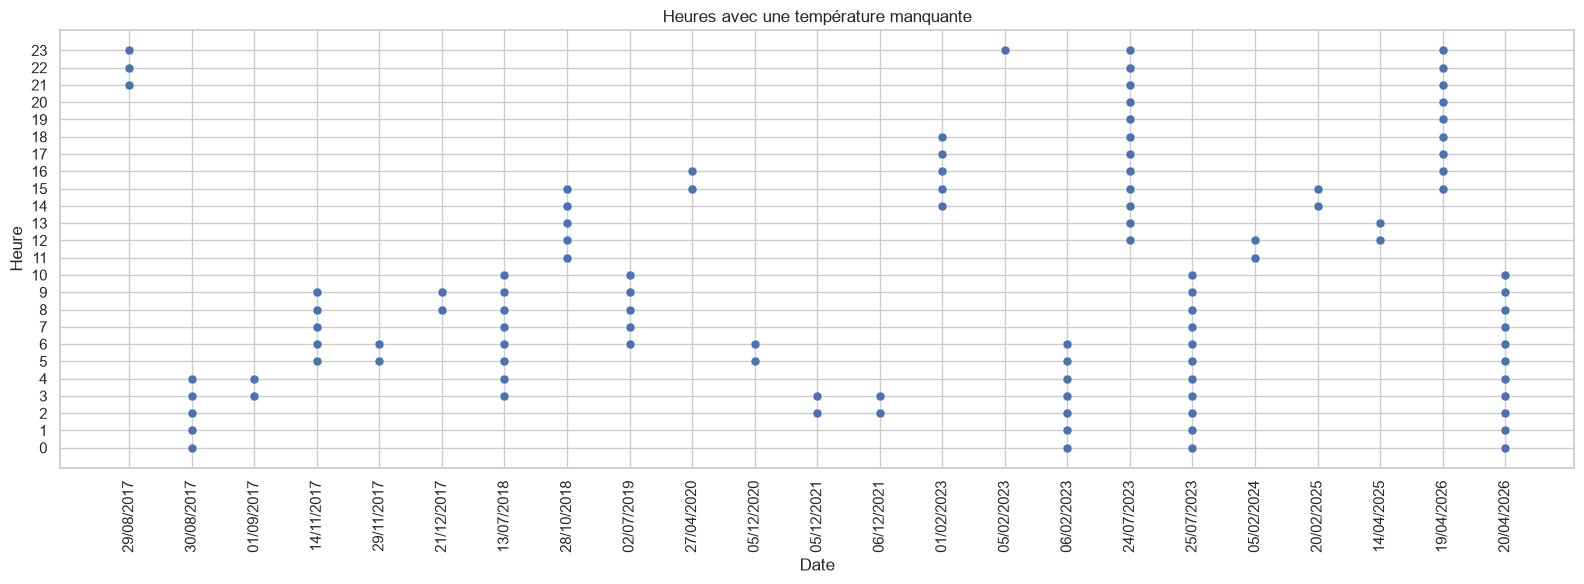

In [47]:
temperature_manquante = df[df["temperature_point_rosee_c_pondere_pop"].isna()].copy()
temperature_manquante["jour"] = temperature_manquante["timestamp_paris"].dt.strftime("%d/%m/%Y")
jours_manquants = temperature_manquante["jour"].drop_duplicates().tolist()

positions = {
    jour: i for i, jour in enumerate(jours_manquants)
}

temperature_manquante["position"] = temperature_manquante["jour"].map(positions)

plt.figure(figsize=(16, 6))
sns.scatterplot(data=temperature_manquante, x="position", y="heure", s=45)
plt.xticks(ticks=range(len(jours_manquants)), labels=jours_manquants, rotation=90)

plt.title("Heures avec une température manquante")
plt.xlabel("Date")
plt.ylabel("Heure")
plt.yticks(range(0, 24))
plt.tight_layout()
plt.show()

In [48]:
print("Consommation minimale :")
print(df.loc[df["consommation_mw"].idxmin()])

print("\nConsommation maximale :")
print(df.loc[df["consommation_mw"].idxmax()])

Consommation minimale :
timestamp_utc                            2020-05-10 05:00:00+00:00
timestamp_paris                          2020-05-10 07:00:00+02:00
consommation_mw                                            29364.5
source_donnee                                  Données définitives
heure                                                            7
jour_semaine                                                     6
jour_annee                                                     131
mois                                                             5
annee                                                         2020
saison                                                   Printemps
confinement_numero                                             1.0
temperature_c                                            15.525641
temperature_point_rosee_c                                13.774359
humidite_pct                                             89.717949
vent_direction_deg                    

## 1. Analyse Séries Temporelles

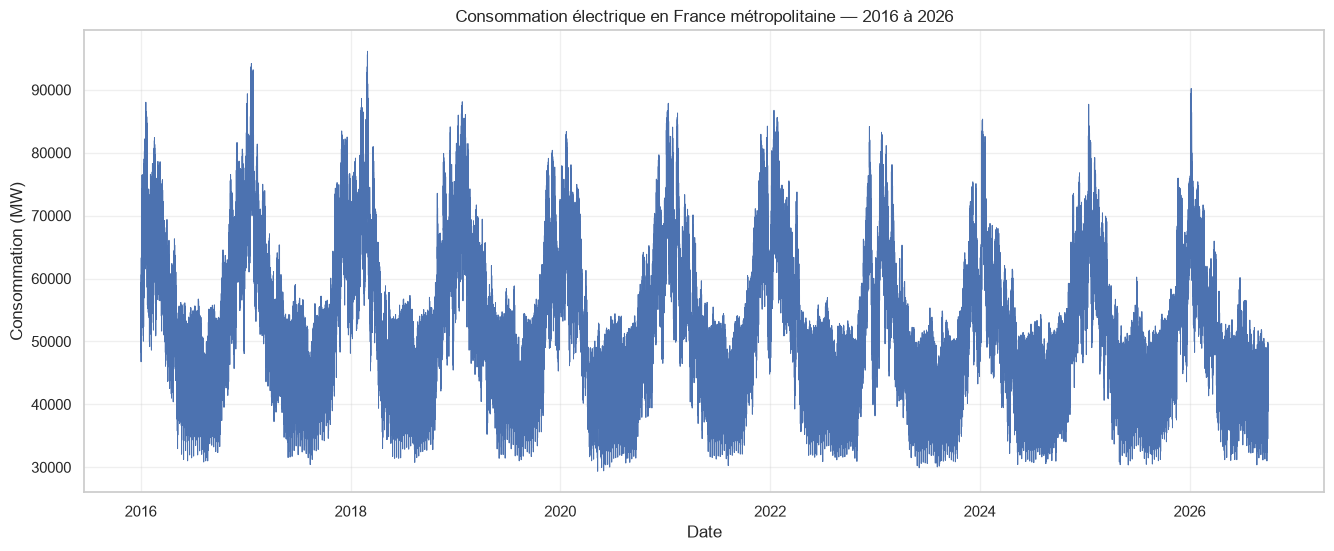

In [49]:
plt.figure(figsize=(16, 6))
plt.plot(
    df["timestamp_paris"],
    df["consommation_mw"],
    linewidth=0.7
)

plt.title("Consommation électrique en France métropolitaine — 2016 à 2026")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
print("Frequence de l'echantillonnage :")
df["timestamp_paris"].diff().value_counts()

Frequence de l'echantillonnage :


timestamp_paris
0 days 01:00:00    94223
Name: count, dtype: int64

### 1.1 Cycle Annuel

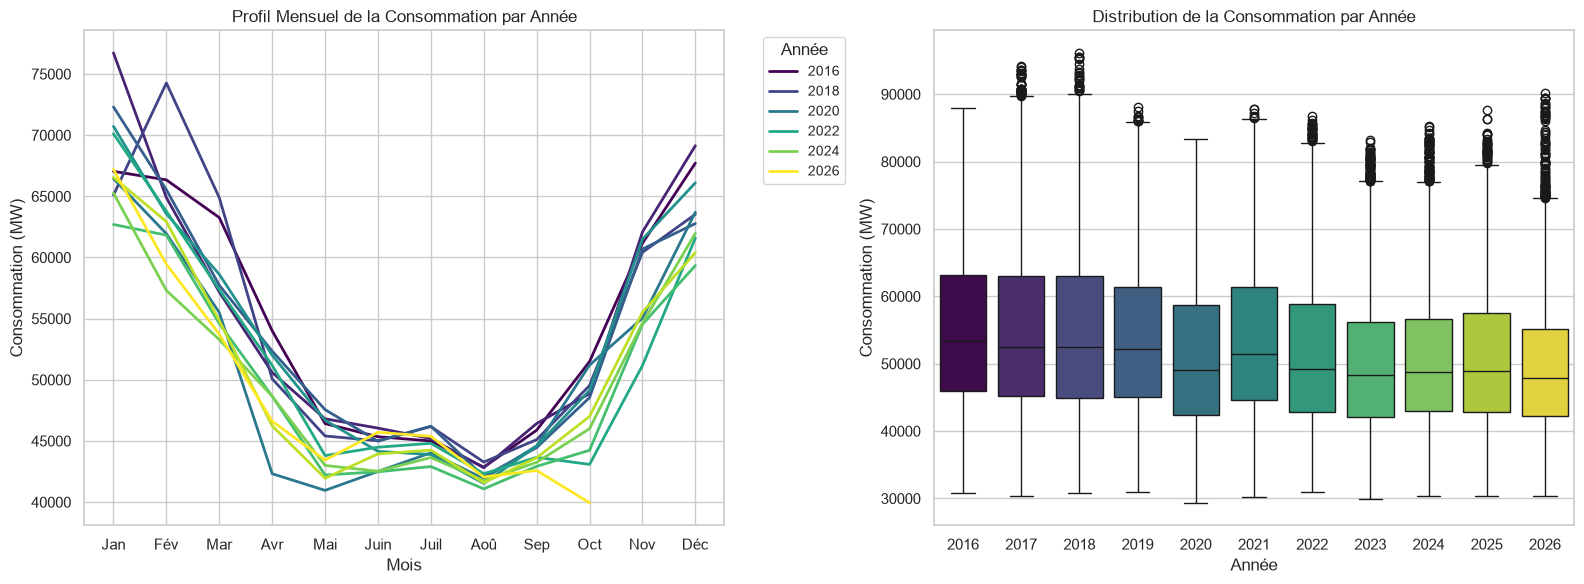

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='mois', y='consommation_mw', hue='annee', ax=axes[0], palette="viridis", errorbar=None, linewidth=2)
axes[0].set_title("Profil Mensuel de la Consommation par Année")
axes[0].set_xlabel("Mois")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MOIS)
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Année", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.boxplot(data=df, x='annee', y='consommation_mw', ax=axes[1], hue='annee', palette="viridis", legend=False)
axes[1].set_title("Distribution de la Consommation par Année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()


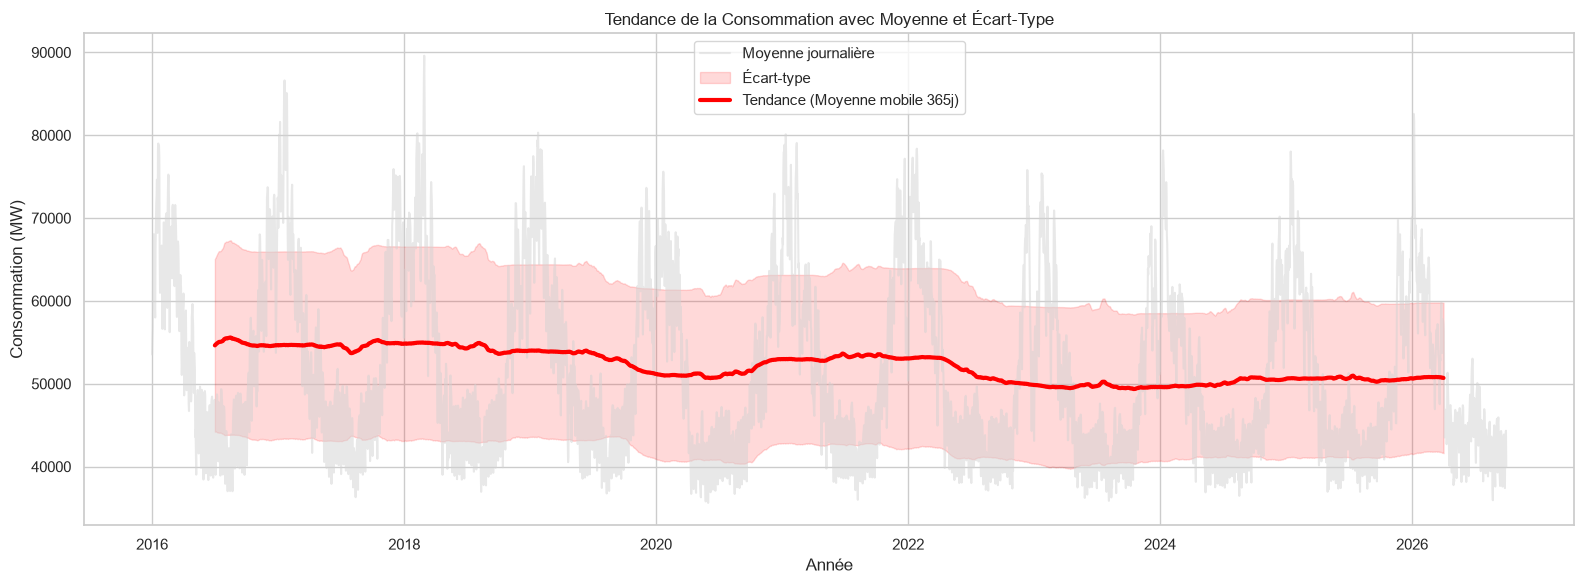

In [52]:
plt.figure(figsize=(16, 6))
df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean().reset_index()

df_daily['moyenne_mobile_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).mean()
df_daily['ecart_type_365j'] = df_daily['consommation_mw'].rolling(window=365, center=True).std()
df_daily['bande_haute'] = df_daily['moyenne_mobile_365j'] + df_daily['ecart_type_365j']
df_daily['bande_basse'] = df_daily['moyenne_mobile_365j'] - df_daily['ecart_type_365j']

sns.lineplot(data=df_daily, x='timestamp_paris', y='consommation_mw', color="lightgray", label="Moyenne journalière", alpha=0.5)

plt.fill_between(
	df_daily['timestamp_paris'], df_daily['bande_basse'], df_daily['bande_haute'], color="red", alpha=0.15, label="Écart-type"
)
sns.lineplot(
	data=df_daily, x='timestamp_paris', y='moyenne_mobile_365j', color="red", linewidth=3, label="Tendance (Moyenne mobile 365j)"
)

plt.title("Tendance de la Consommation avec Moyenne et Écart-Type")
plt.xlabel("Année")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.tight_layout()
plt.show()

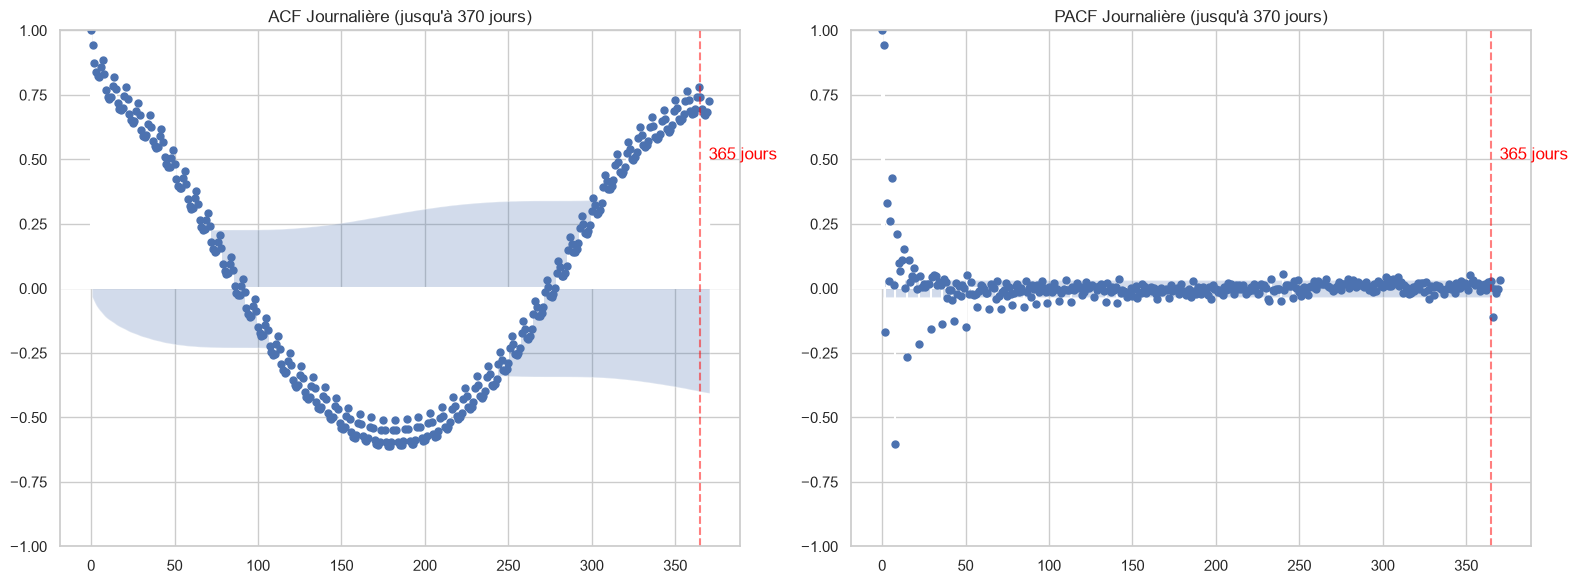

In [53]:
df_daily = df.groupby(df['timestamp_paris'].dt.date)['consommation_mw'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=370, ax=axes[0], title="ACF Journalière (jusqu'à 370 jours)")
plot_pacf(df_daily['consommation_mw'], lags=370, ax=axes[1], title="PACF Journalière (jusqu'à 370 jours)")

axes[0].axvline(x=365, color='red', linestyle='--', alpha=0.5)
axes[0].text(370, 0.5, '365 jours', color='red')

axes[1].axvline(x=365, color='red', linestyle='--', alpha=0.5)
axes[1].text(370, 0.5, '365 jours', color='red')

plt.tight_layout()
plt.show()

Inter-annuel :
- Il y a pas de saisonalité, tendance ou cycle.
- Moyenne et écart avant Covid != pendant Covid != après Covid.
- Mais la moyenne et écart après Covid sont stable.

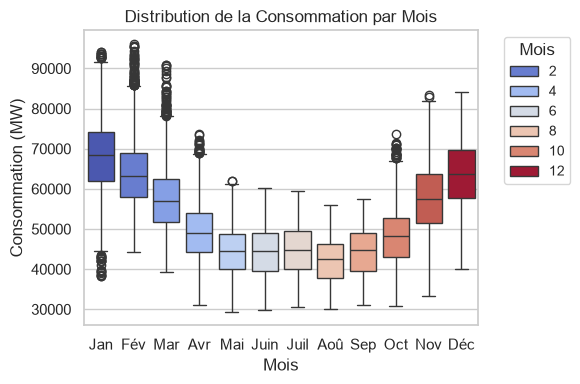

In [54]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

sns.boxplot(data=df, x='mois', y='consommation_mw', ax=axes, hue='mois', palette="coolwarm")
axes.set_title("Distribution de la Consommation par Mois")
axes.set_xlabel("Mois")
axes.set_xticks(range(12))
axes.set_xticklabels(MOIS)
axes.set_ylabel("Consommation (MW)")
axes.legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

Annuelle :
- Il y a une saisonalité.
- Il y a pas de tendance ou cycle.

### 1.2 Cycle Mensuel

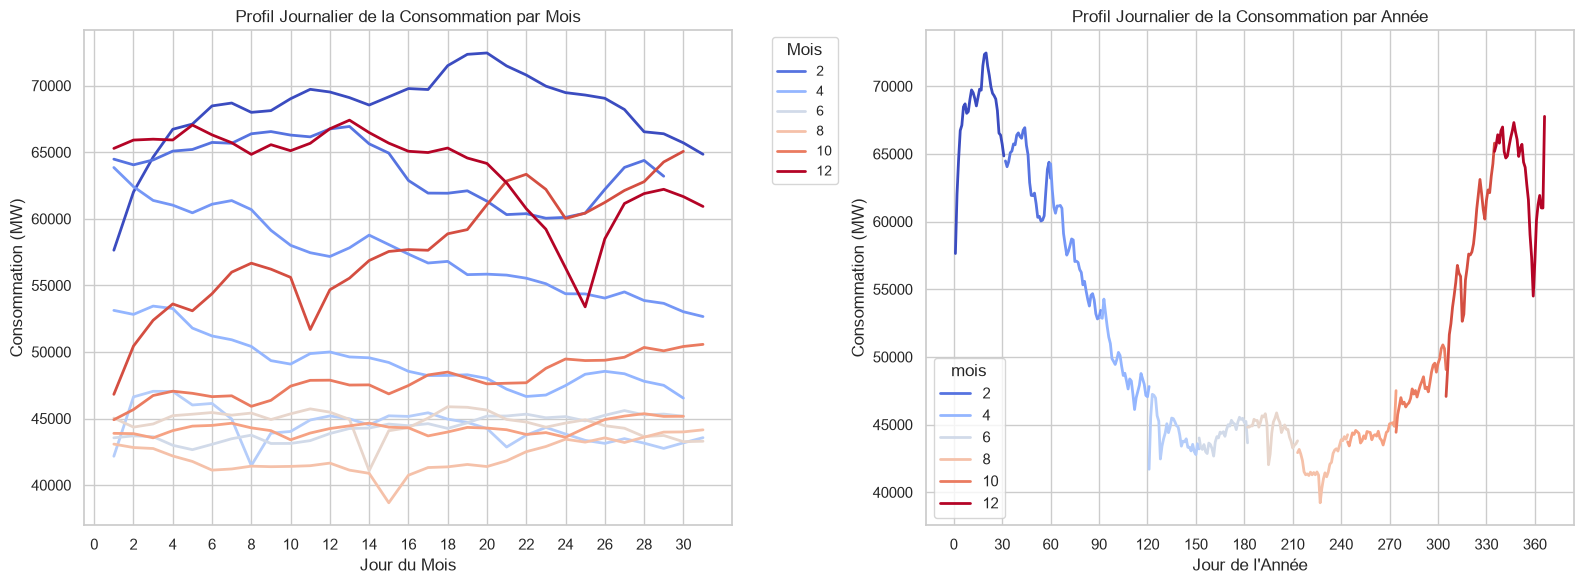

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['jour_mois'] = df['timestamp_paris'].dt.day

sns.lineplot(data=df, x='jour_mois', y='consommation_mw', hue='mois', ax=axes[0], palette="coolwarm", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Mois")
axes[0].set_xlabel("Jour du Mois")
axes[0].set_xticks(range(0, 32, 2))
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Mois", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


sns.lineplot(data=df, x='jour_annee', y='consommation_mw', hue='mois', ax=axes[1], palette="coolwarm", errorbar=None, linewidth=2)
axes[1].set_title("Profil Journalier de la Consommation par Année")
axes[1].set_xlabel("Jour de l'Année")
axes[1].set_xticks(range(0, 366, 30))
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

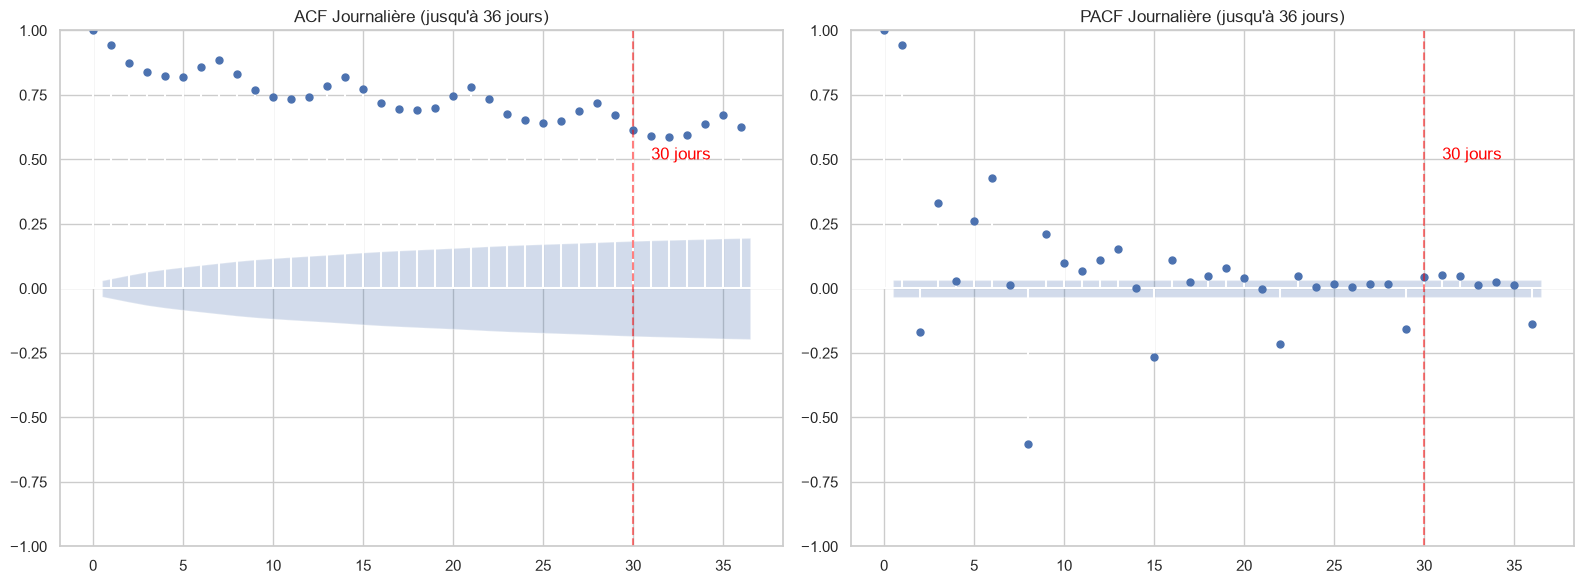

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=36, ax=axes[0], title="ACF Journalière (jusqu'à 36 jours)")
plot_pacf(df_daily['consommation_mw'], lags=36, ax=axes[1], title="PACF Journalière (jusqu'à 36 jours)")

axes[0].axvline(x=30, color='red', linestyle='--', alpha=0.5)
axes[0].text(31, 0.5, '30 jours', color='red')

axes[1].axvline(x=30, color='red', linestyle='--', alpha=0.5)
axes[1].text(31, 0.5, '30 jours', color='red')

plt.tight_layout()
plt.show()

Mensuelle :
- Il y a pas de tendance, cycle, ou saisonalité mensuelle.
- Il y a des trous qui correspondent à des vacances.

### 1.3 Cycle Hebdomadaire

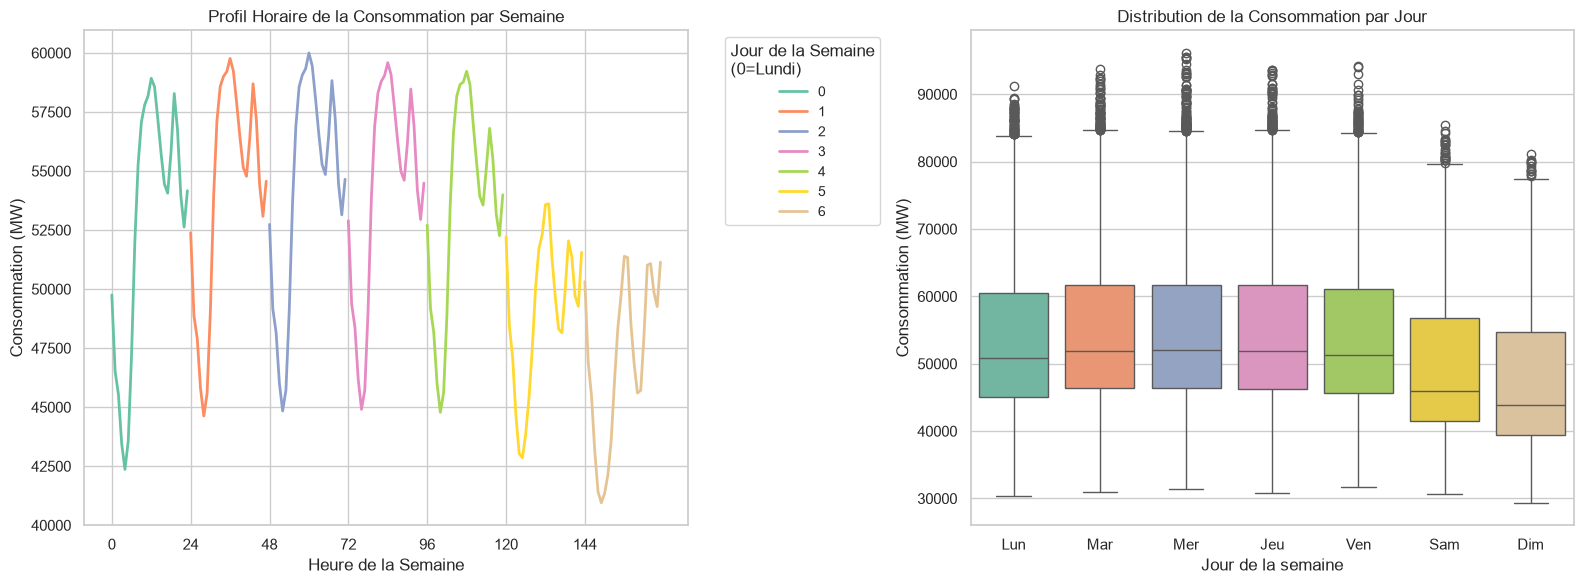

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['heure_semaine'] = df['timestamp_paris'].dt.hour + df['timestamp_paris'].dt.weekday * 24

sns.lineplot(
	data=df, x='heure_semaine', y='consommation_mw', hue='jour_semaine', ax=axes[0], palette="Set2", errorbar=None, linewidth=2
)
axes[0].set_title("Profil Horaire de la Consommation par Semaine")
axes[0].set_xlabel("Heure de la Semaine")
axes[0].set_xticks(range(0, 168, 24))
axes[0].set_ylabel("Consommation (MW)")
axes[0].legend(title="Jour de la Semaine\n(0=Lundi)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.boxplot(data=df, x='jour_semaine', y='consommation_mw', ax=axes[1], hue='jour_semaine', palette="Set2", legend=False)
axes[1].set_title("Distribution de la Consommation par Jour")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(JOURS_SEMAINE)
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

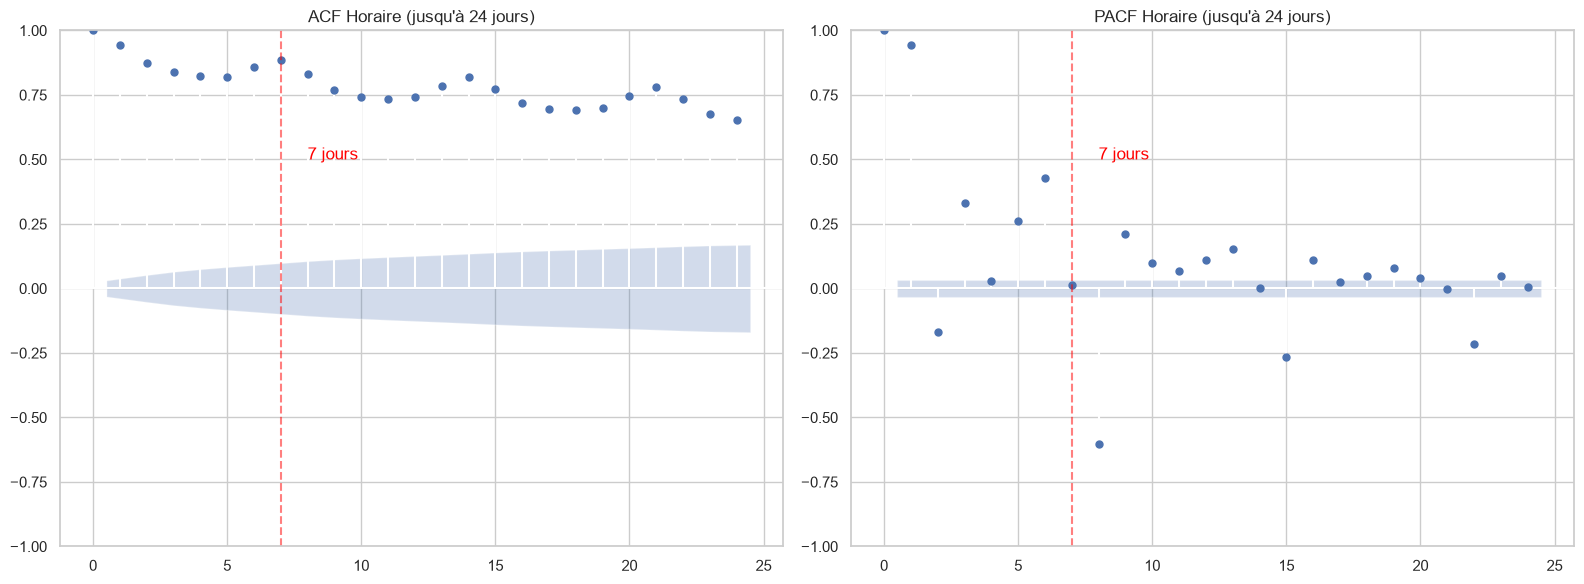

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df_daily['consommation_mw'], lags=24, ax=axes[0], title="ACF Horaire (jusqu'à 24 jours)")
plot_pacf(df_daily['consommation_mw'], lags=24, ax=axes[1], title="PACF Horaire (jusqu'à 24 jours)")

axes[0].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[0].text(8, 0.5, '7 jours', color='red')

axes[1].axvline(x=7, color='red', linestyle='--', alpha=0.5)
axes[1].text(8, 0.5, '7 jours', color='red')

plt.tight_layout()
plt.show()

Hebdomadaire :
- Il y une saisonnalité hebdomadaire.

### 1.4 Cycle Journalier

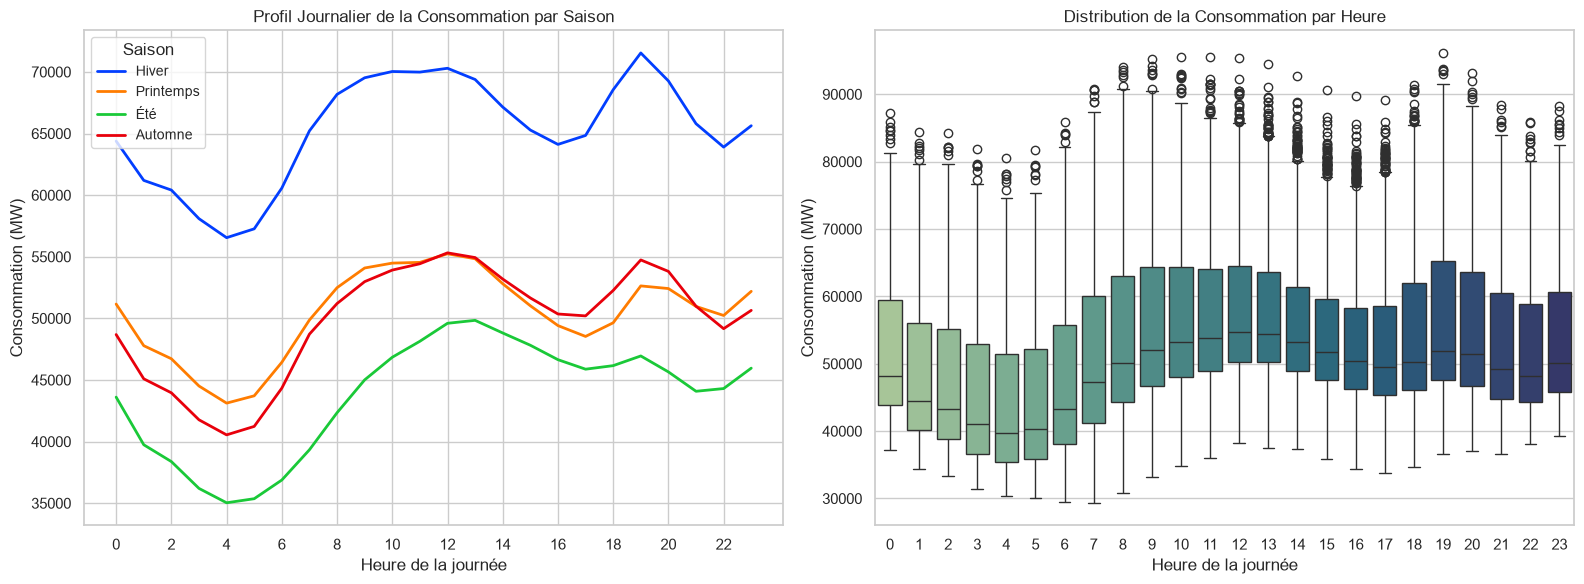

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x='heure', y='consommation_mw', hue='saison', ax=axes[0], palette="bright", errorbar=None, linewidth=2)
axes[0].set_title("Profil Journalier de la Consommation par Saison")
axes[0].legend(title="Saison", loc='upper left', fontsize='small')
axes[0].set_xlabel("Heure de la journée")
axes[0].set_ylabel("Consommation (MW)")
axes[0].set_xticks(range(0, 24, 2))

sns.boxplot(data=df, x='heure', y='consommation_mw', ax=axes[1], hue='heure', palette="crest", legend=False)
axes[1].set_title("Distribution de la Consommation par Heure")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

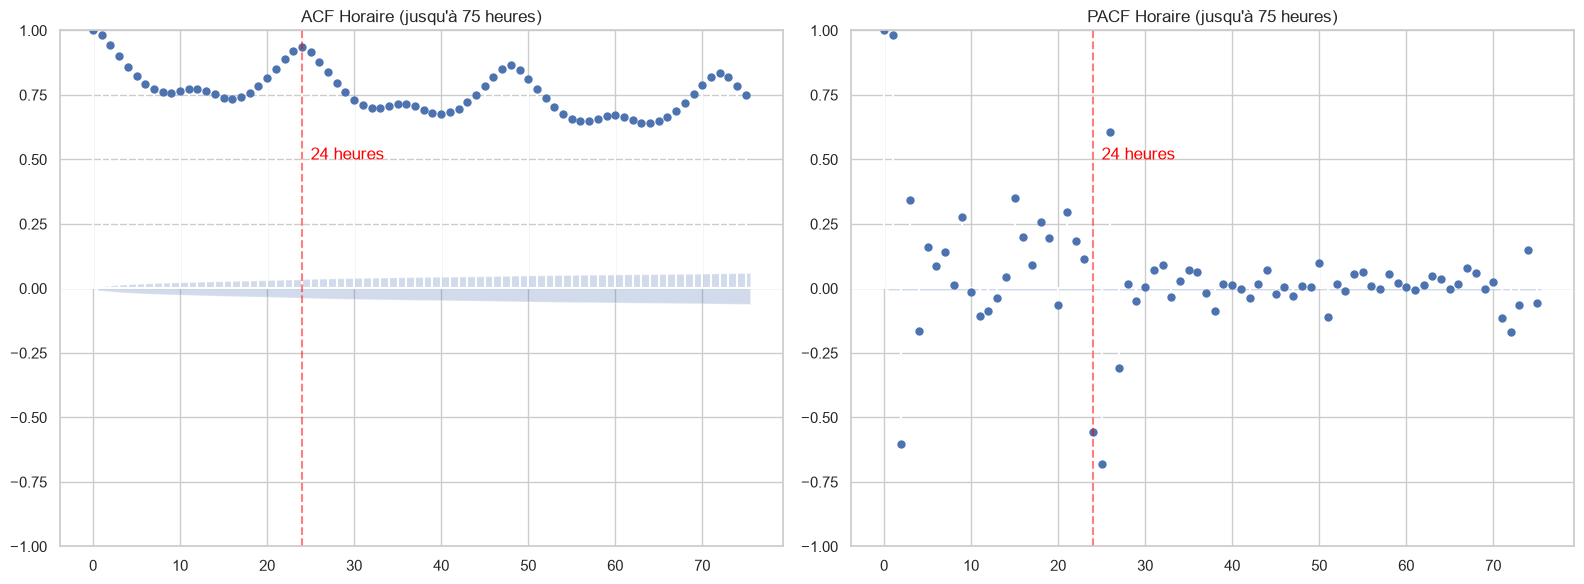

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(df['consommation_mw'], lags=75, ax=axes[0], title="ACF Horaire (jusqu'à 75 heures)")
plot_pacf(df['consommation_mw'], lags=75, ax=axes[1], title="PACF Horaire (jusqu'à 75 heures)")

axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5)
axes[0].text(25, 0.5, '24 heures', color='red')

axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.5)
axes[1].text(25, 0.5, '24 heures', color='red')

plt.tight_layout()
plt.show()

Journalière :
- Il y a pas de tendance ou cycle journalière.
- Il y a une saisonalité journalière.

### 1.5. Conclusion
- Il y a pas de tendance ou de cycle.
- Il y a pas de l'amplitude => Bon pour Meta Prophet.
- Il y a des saisonalité annuelle, hebdomadaire, et journalière => Bon pour XGBoost, Prophet, Regression Fourier, modifier SARIMAX.
- La Covid a un impact, après et avant sont différent => Bon pour XGBoost.

## 2. Relation avec la Météo

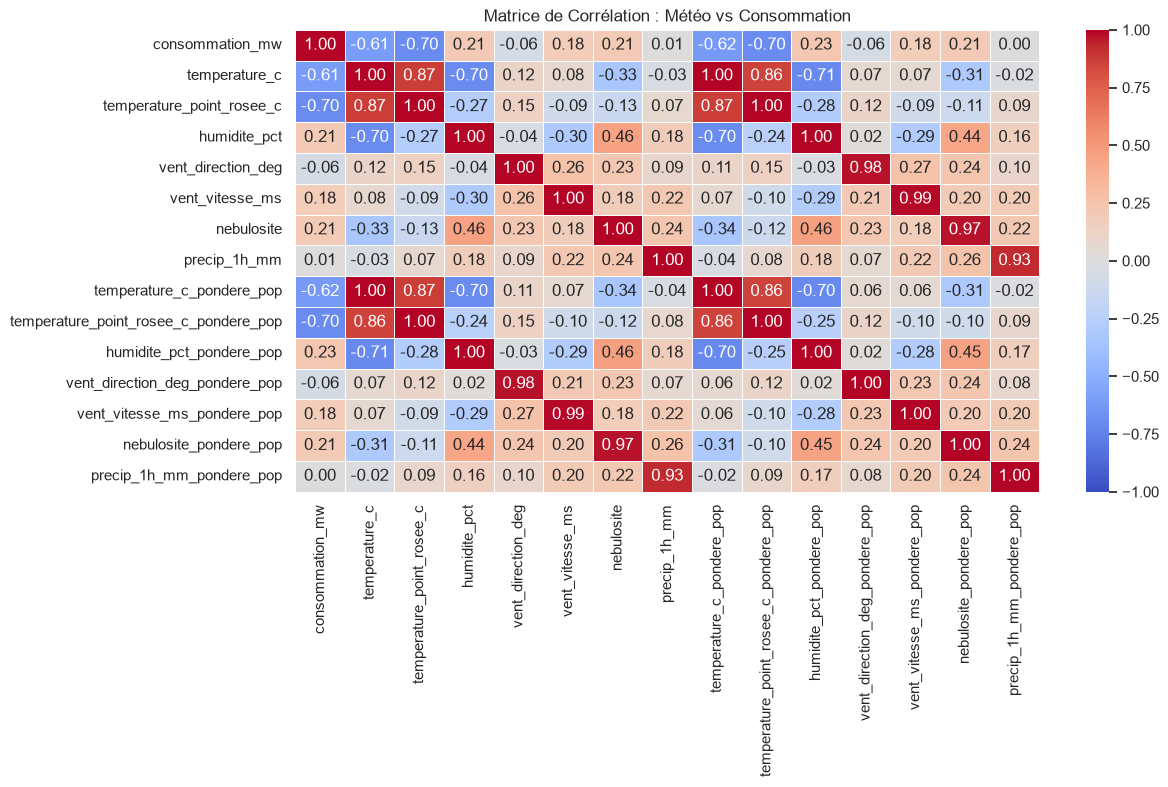

In [61]:
cols_meteo = [
    c for c in df.columns
    if ('temperature' in c or 'humidite' in c or 'vent' in c or 'nebulosite' in c or 'precip' in c)
]

cols_corr = ['consommation_mw'] + cols_meteo
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation : Météo vs Consommation")
plt.show()

- `temperature_c_pondere_pop` et `temperature_point_rosee_c_pondere_pop` sont bons.
- Mais ils sont très corrélés donc on enlève `temperature_c_pondere_pop` et `humidite` aussi.
- Mais il faut tester aussi les autres (sauf `vent_direction`).

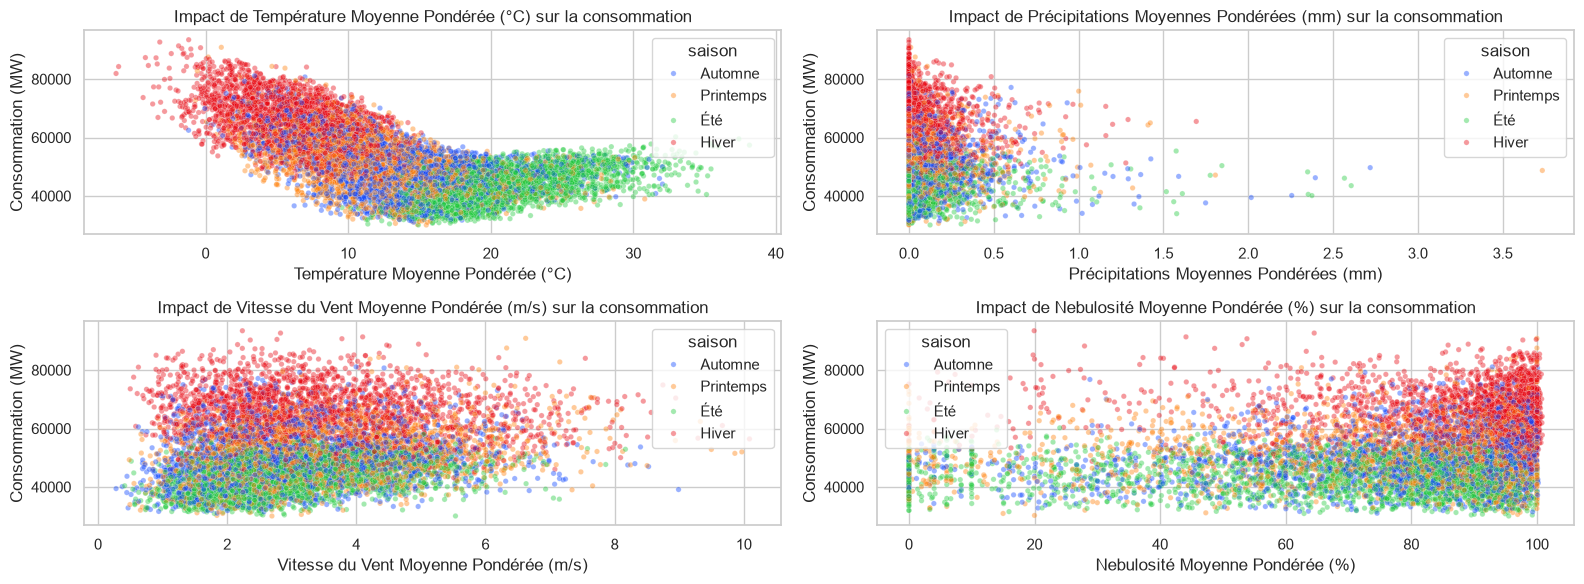

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6))

variables = [
	("temperature_c_pondere_pop", "Température Moyenne Pondérée (°C)"),
    ("precip_1h_mm_pondere_pop", "Précipitations Moyennes Pondérées (mm)"),
    ("vent_vitesse_ms_pondere_pop", "Vitesse du Vent Moyenne Pondérée (m/s)"),
    ("nebulosite_pondere_pop", "Nebulosité Moyenne Pondérée (%)"),
]

for ax, (column, label) in zip(axes.flat, variables):
    sns.scatterplot(
        data=df.sample(frac=0.1, random_state=42),
        x=column,
        y="consommation_mw",
        hue="saison",
        alpha=0.4,
        s=15,
        palette="bright",
        ax=ax
    )

    ax.set_title(f"Impact de {label} sur la consommation")
    ax.set_xlabel(label)
    ax.set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

## 3. Effets Calendaires (Fériés & Vacances)

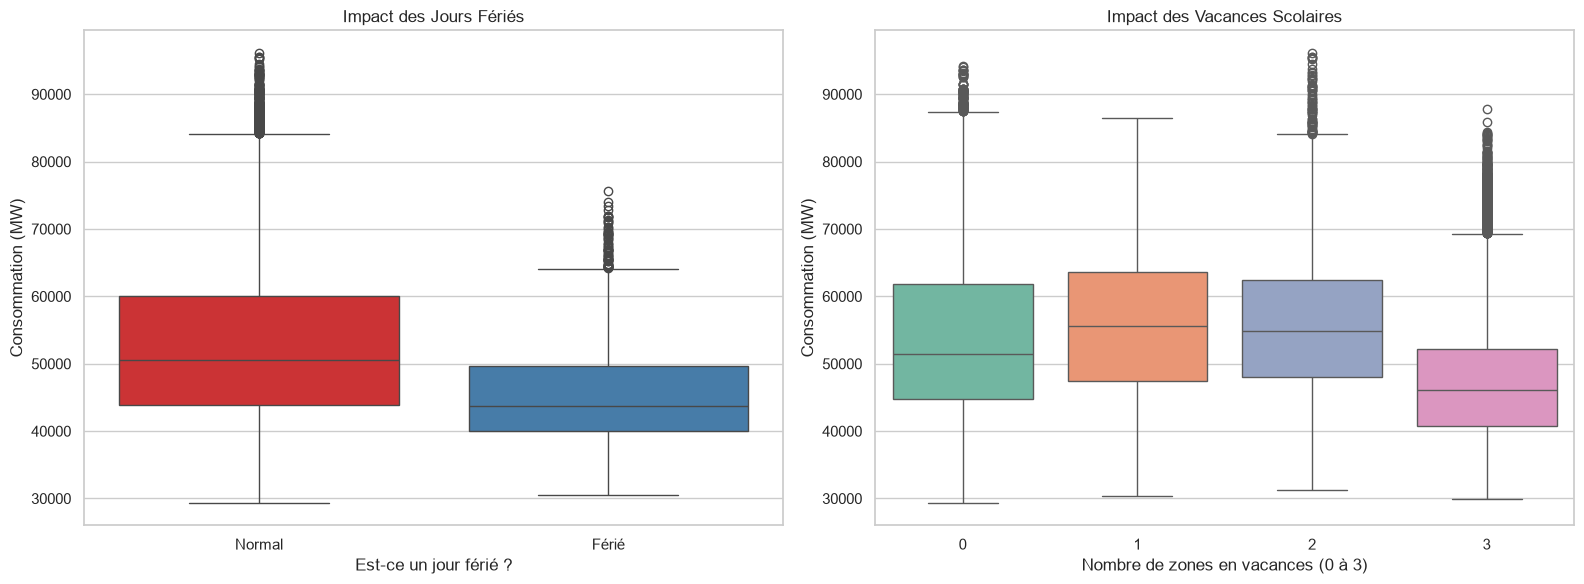

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='ferie', y='consommation_mw', ax=axes[0], hue='ferie', palette="Set1", legend=False)
axes[0].set_title("Impact des Jours Fériés")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Férié'])
axes[0].set_xlabel("Est-ce un jour férié ?")
axes[0].set_ylabel("Consommation (MW)")

sns.boxplot(data=df, x='vacances', y='consommation_mw', ax=axes[1], hue='vacances', palette="Set2", legend=False)
axes[1].set_title("Impact des Vacances Scolaires")
axes[1].set_xlabel("Nombre de zones en vacances (0 à 3)")
axes[1].set_ylabel("Consommation (MW)")

plt.tight_layout()
plt.show()

## 4. Impact de la COVID

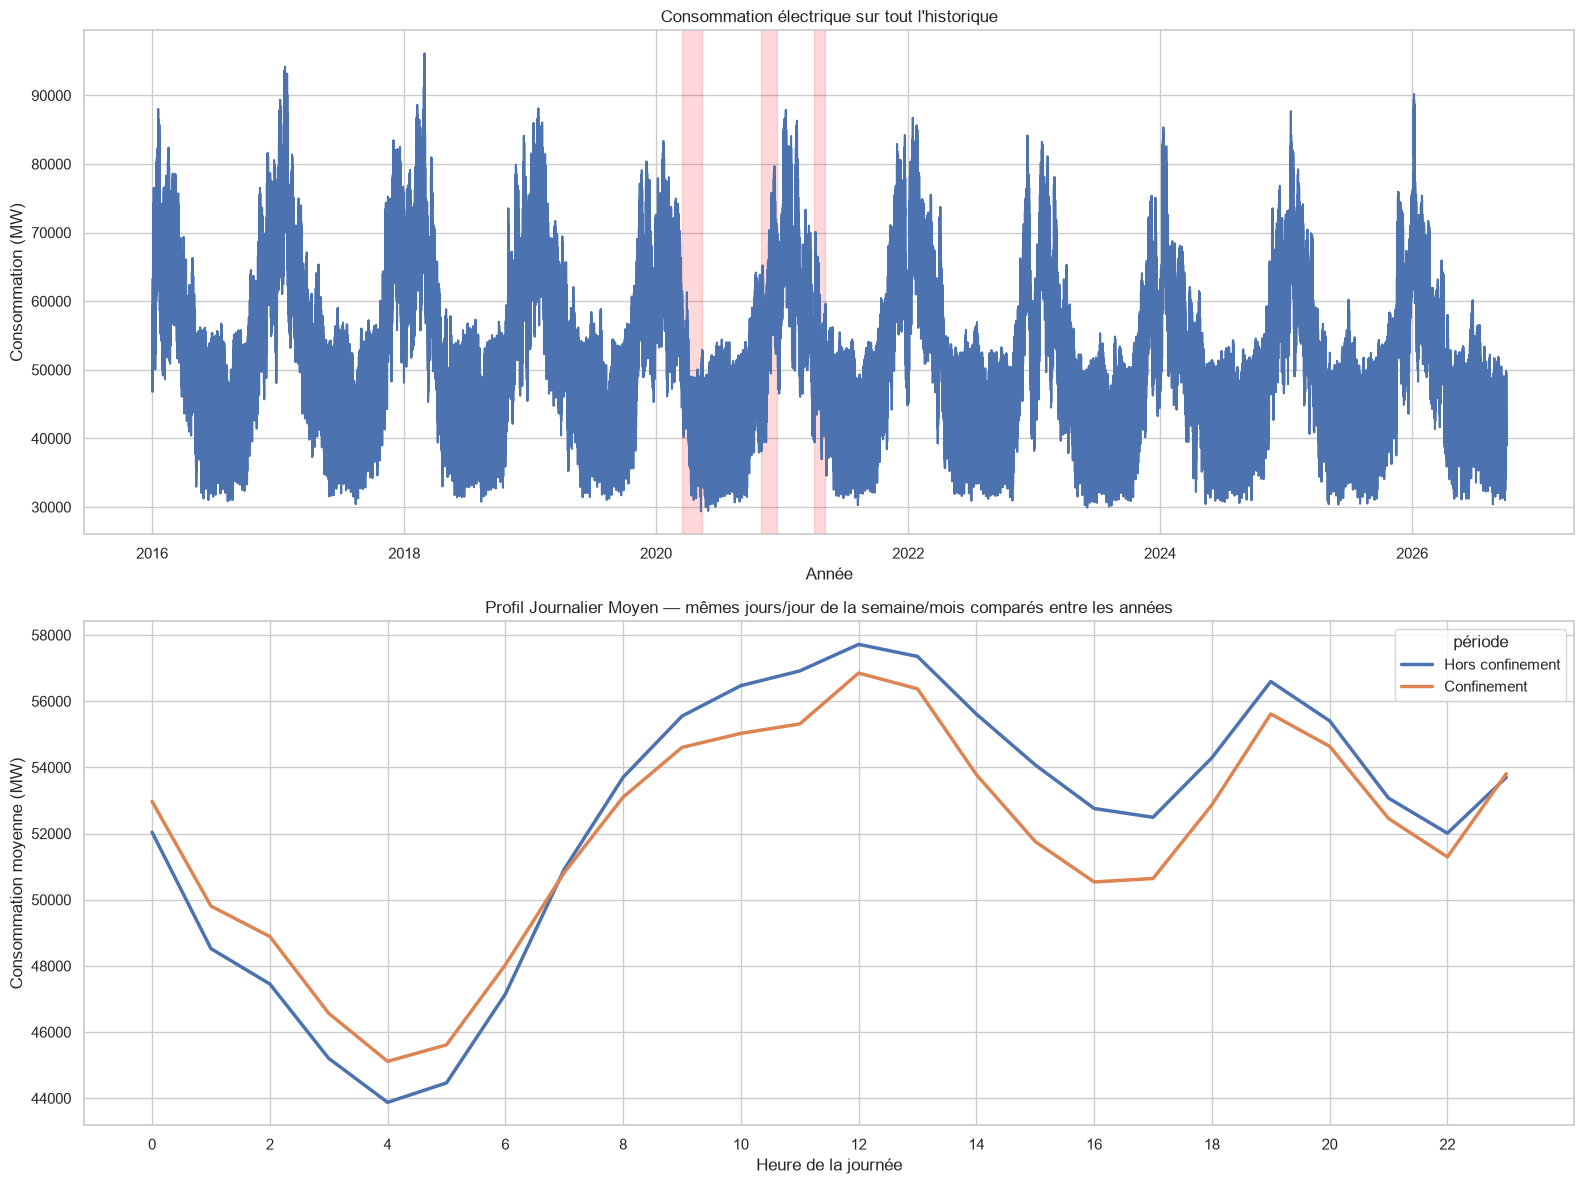

In [64]:
df_compare = df.copy()

df_compare["est_confinement"] = (df_compare["confinement_numero"] > 0).astype(int)

df_compare["période"] = np.where(
    df_compare["est_confinement"] == 1,
    "Confinement",
    "Hors confinement"
)

comparison = (
    df_compare
        .groupby(["mois", "jour_semaine", "heure", "est_confinement", "période"])["consommation_mw"]
        .mean()
        .reset_index()
)

hourly_comparison = (
    comparison
        .groupby(["heure", "est_confinement", "période"])["consommation_mw"]
        .mean()
        .reset_index()
)

periodes_confinement = (
    df[df["confinement_numero"] > 0]
    .groupby("confinement_numero")["timestamp_paris"]
    .agg(["min", "max"])
)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.lineplot(data=df, x="timestamp_paris", y="consommation_mw", ax=axes[0])

for confinement, periode in periodes_confinement.iterrows():
    debut = periode["min"].tz_localize(None)
    fin = periode["max"].tz_localize(None)

    axes[0].axvspan(debut, fin, color="red", alpha=0.15)


axes[0].set_title("Consommation électrique sur tout l'historique")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Consommation (MW)")

sns.lineplot(
    data=hourly_comparison, x="heure", y="consommation_mw", hue="période",
    hue_order=["Hors confinement", "Confinement"], ax=axes[1], linewidth=2.5
)

axes[1].set_title("Profil Journalier Moyen — mêmes jours/jour de la semaine/mois comparés entre les années")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Consommation moyenne (MW)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

STL?
tendance?

## Conclusion

La série présente . . .
Je soupçonne une saisonnalité de période . . .parce que . . .
L’ACF montre . . .
La PACF suggère que . . .
Avant de la modéliser, je voudrais vérifier / transformer . . .



Employer correctement : fréquence, période, retard, horizon, tendance, saisonnalité,
cycle, résidu.
Expliquer pourquoi l’ordre temporel contient de l’information.
Choisir entre une lecture additive et multiplicative simple.
Expliquer le rôle d’une moyenne mobile et d’une décomposition.
Définir et interpréter l’ACF.
Reconnaître persistance, saisonnalité et faible mémoire dans un corrélogramme.
Expliquer l’idée de la PACF sans recourir à une recette de choix de modèle.



many params.


Recursive approach because our horizon is only 24 days.
Can reuse previsions?


Uncertainty?
On vous donne une série, son ACF/PACF, deux modèles estimés et leurs résidus.
1 La série semble-t-elle stationnaire ? Pourquoi ?
2 Quelle transformation proposeriez-vous si nécessaire ?
3 Quel mécanisme AR/MA/ARMA est plausible ?
4 Quel modèle retenez-vous après estimation ?
5 Les résidus permettent-ils de valider provisoirement ce choix ?

AIC/BIC
stability in time?
cost?

Ali
SARIMAX => modifié/limites, stationarity, diff + diff saison, correction saison ? transformation ? justifier avec ACF, PACF <-> candidats, plot residues, ACF residues, Ljung–Box.

Asma
XGBoost => Bon
- Feature engineering C[J], C[J-7], C[J-365], C[J-366], T[J], T[J-7],...
- Unstable, overfit?
- Intepretable
LSTM => Bon, T[J, <=14h], T[J-1], T[J-7], T[J-365], T[J-366]

Dang
References
Prophet par Meta
Regression => Linear / Fourier.

Why not historical mean?